In [29]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
batch_by_alph = CheckPoint.from_pt(path="models/copy_batching_strategies/MLC_batchalph_dallstudy1_incl_copy_fixedgen_nep20.pt")
model = batch_by_alph.load_model()
model.eval()
val = batch_by_alph.load_dataloaders(data_dir=batch_by_alph.train_config.dir_data, use_datasets=["val"])[0]

Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 230,960
	best val loss achieved: 0.6848
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loaded following dataloaders:
val dataloader (n=46,158)


In [31]:
batch = next(iter(val))

In [39]:
model.eval()
# get source mask (i.e., mask padded elements in the batch):
src, src_key_padding_mask = model.prep_encode(batch['xq_context_padded'])
src_mask = None
src_key_padding_mask = F._canonical_mask(
        mask=src_key_padding_mask,
        mask_name="src_key_padding_mask",
        other_type=F._none_or_dtype(src_mask),
        other_name="src_mask",
        target_type=src.dtype,
    )
src_mask = F._canonical_mask(
    mask=src_mask,
    mask_name="src_mask",
    other_type=None,
    other_name="",
    target_type=src.dtype,
    check_other=False,
)
x = src
# get averaged attention matrix from current layer
_, attn_weights = model.transformer.encoder.layers[0].self_attn(
    x,
    x,
    x,
    attn_mask=src_mask,
    key_padding_mask=src_key_padding_mask,
    need_weights=True,
    is_causal=False
)
attn_weights

tensor([[[0.0545, 0.0105, 0.0050,  ..., 0.0000, 0.0000, 0.0000],
         [0.0087, 0.1282, 0.0058,  ..., 0.0000, 0.0000, 0.0000],
         [0.0073, 0.0049, 0.0734,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0085, 0.0140, 0.0276,  ..., 0.0000, 0.0000, 0.0000],
         [0.0096, 0.0145, 0.0211,  ..., 0.0000, 0.0000, 0.0000],
         [0.0101, 0.0157, 0.0180,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0370, 0.0091, 0.0115,  ..., 0.0000, 0.0000, 0.0000],
         [0.0141, 0.1292, 0.0146,  ..., 0.0000, 0.0000, 0.0000],
         [0.0093, 0.0052, 0.0461,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0098, 0.0117, 0.0262,  ..., 0.0000, 0.0000, 0.0000],
         [0.0095, 0.0115, 0.0178,  ..., 0.0000, 0.0000, 0.0000],
         [0.0117, 0.0132, 0.0175,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0308, 0.0066, 0.0040,  ..., 0.0000, 0.0000, 0.0000],
         [0.0074, 0.1259, 0.0043,  ..., 0.0000, 0.0000, 0.0000],
         [0.0064, 0.0033, 0.0365,  ..., 0.0000, 0.0000, 0.

In [40]:
attn_weights.shape

torch.Size([25, 72, 72])

In [41]:
idx = 3
batch["xq_context"][idx]

['a',
 'b',
 'g',
 'd',
 'e',
 'f',
 's',
 'h',
 'i',
 'j',
 'w',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 'k',
 't',
 'u',
 'v',
 'c',
 'x',
 'y',
 'z',
 'SOS',
 'c',
 'o',
 'y',
 'IO',
 'c',
 'x',
 'y',
 'z',
 'SOS',
 'c',
 'o',
 'y']

In [59]:
example_length = len(batch["xq_context"][idx])
weights = attn_weights[idx, :example_length, :example_length].detach().cpu().numpy()  # shape: [seq_len, seq_len]
weights

array([[0.05214974, 0.01065326, 0.00703319, ..., 0.00146876, 0.00215717,
        0.01082794],
       [0.01097977, 0.12908028, 0.00805203, ..., 0.00179777, 0.00144624,
        0.00095284],
       [0.01122018, 0.00678151, 0.08005186, ..., 0.00083287, 0.0021284 ,
        0.00139067],
       ...,
       [0.00774727, 0.00263086, 0.00445924, ..., 0.00530044, 0.00153373,
        0.00465077],
       [0.00395507, 0.00225455, 0.00482129, ..., 0.00033719, 0.00402754,
        0.00109727],
       [0.00345616, 0.00199699, 0.00434309, ..., 0.00142125, 0.00083877,
        0.00463922]], shape=(39, 39), dtype=float32)

In [60]:
weights.shape

(39, 39)

In [58]:
_, weights_by_head = model.transformer.encoder.layers[0].self_attn(
    x,
    x,
    x,
    attn_mask=src_mask,
    key_padding_mask=src_key_padding_mask,
    need_weights=True,
    is_causal=False,
    average_attn_weights=False
)
#weights_by_head = weights_by_head[idx, :example_length, :example_length].detach().cpu().numpy()  # shape: [seq_len, seq_len]
weights_by_head.shape

torch.Size([25, 8, 72, 72])

In [ ]:
np.sum(weights_by_head, axis=1)

In [61]:
weights_head1 = weights_by_head[idx, 0, :example_length, :example_length].detach().cpu().numpy()  # shape: [seq_len, seq_len]
weights_head1.shape

(39, 39)

In [65]:
np.sum(weights_head1, axis=1)
# apply softmax to one of the dimensions??

array([0.9577675 , 0.971597  , 0.9741728 , 0.98173004, 0.99617225,
       0.99503404, 0.98420304, 0.978093  , 0.9848781 , 0.964349  ,
       0.9747663 , 0.9880447 , 0.96777886, 0.9850546 , 0.9877702 ,
       0.99154645, 0.9955274 , 0.9897244 , 0.973365  , 0.9437642 ,
       0.97760457, 0.9725725 , 0.94712657, 0.9002092 , 0.8826253 ,
       0.81210625, 0.96831465, 0.88758165, 0.9707935 , 0.96036613,
       0.95487297, 0.73730403, 0.92834646, 0.9930917 , 0.99815863,
       0.999942  , 0.9999229 , 0.99964464, 0.95059884], dtype=float32)

In [51]:
weights[:,30]

array([0.30736777, 0.2716195 , 0.3188806 , 0.28804466, 0.2680427 ,
       0.26986104, 0.28260148, 0.28376344, 0.30000415, 0.2872195 ,
       0.27461526, 0.27246347, 0.28848106, 0.29334936, 0.32466558,
       0.30909914, 0.29368457, 0.29939282, 0.33659562, 0.33726197,
       0.39957833, 0.4197247 , 0.4002313 , 0.45982295, 0.37517115,
       0.31998184, 0.15455803, 0.17759046, 0.24011737, 0.2882976 ,
       0.19995853, 0.45949522, 0.49998218, 0.36677247, 0.33235547,
       0.3131489 , 0.4087285 , 0.5114975 , 0.5233915 ], dtype=float32)

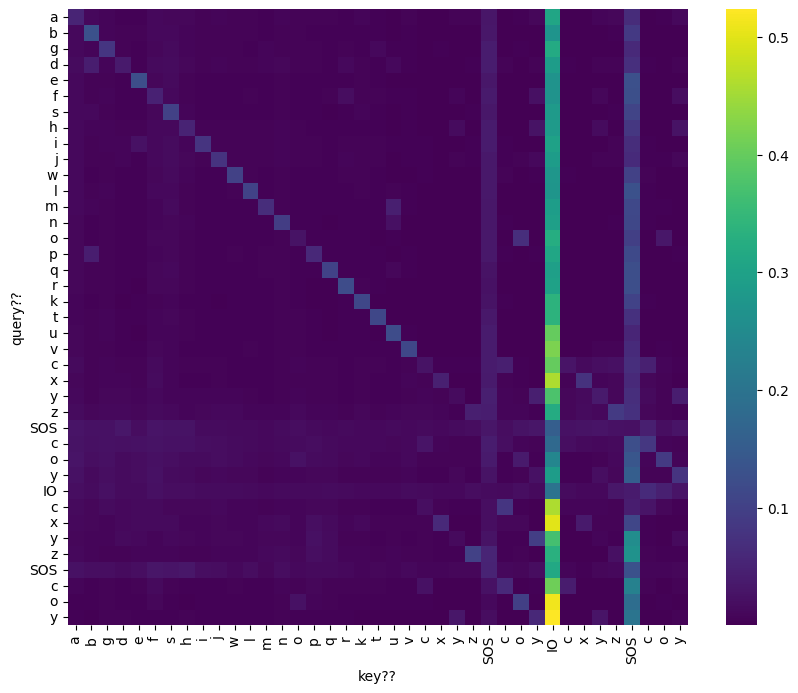

In [53]:
_ = plt.figure(figsize=(10,8))
_ = sns.heatmap(weights, cmap="viridis", xticklabels=batch["xq_context"][idx], yticklabels=batch["xq_context"][idx])
_ = plt.xlabel("key??")
_ = plt.ylabel("query??")

In [ ]:
batch_size = len(batch['yq'])
xq_context_padded = batch['xq_context_padded'] # batch_size x maxlen_src
src_embed, src_padding_mask = model.prep_encode(xq_context_padded)

emission_lang = val.dataset.langs["output"]
z_padded = torch.tensor([emission_lang.IN_OUT_idx]*batch_size, device=DEVICE)
z_padded = z_padded.unsqueeze(1)
tgt_embed, tgt_padding_mask, tgt_mask = model.prep_decode(z_padded)

trans_out = model.transformer(src_embed, tgt_embed, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask, tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask)

output = model.out(trans_out)

In [ ]:

encoder_layer = model.transformer.encoder.layers[0]

src, src_key_padding_mask = model.prep_encode(batch['xq_context_padded'])


src = src_embed
src_key_padding_mask=src_padding_mask
src_mask = None
src_key_padding_mask = F._canonical_mask(
            mask=src_key_padding_mask,
            mask_name="src_key_padding_mask",
            other_type=F._none_or_dtype(src_mask),
            other_name="src_mask",
            target_type=src.dtype,
        )
src_mask = F._canonical_mask(
    mask=src_mask,
    mask_name="src_mask",
    other_type=None,
    other_name="",
    target_type=src.dtype,
    check_other=False,
)

In [ ]:
src_embed.shape

torch.Size([25, 78, 128])

In [ ]:
batch["xq_context_padded"].shape

torch.Size([25, 78])

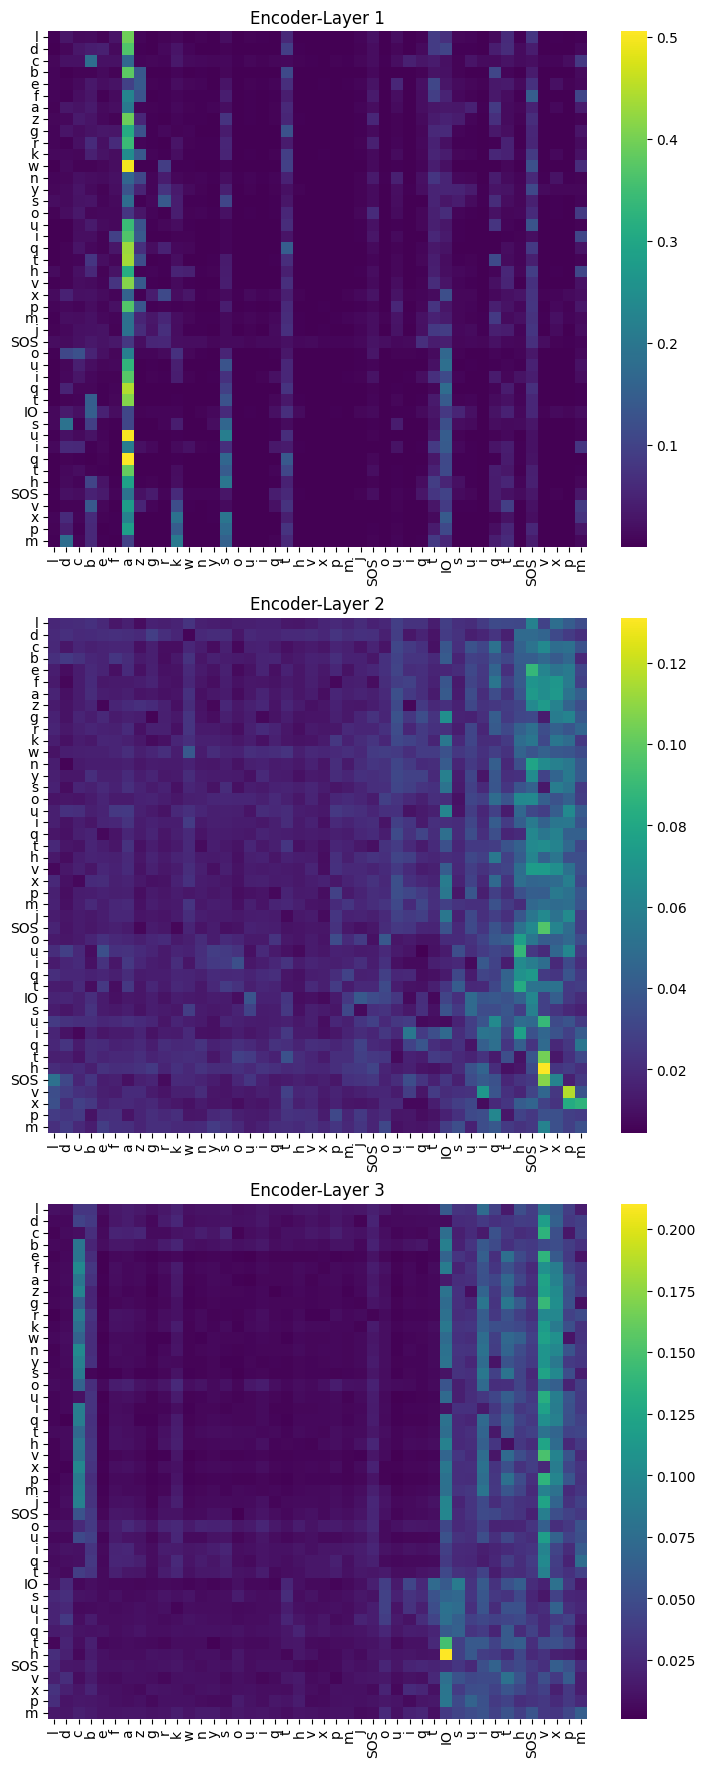

In [ ]:
def get_encoder_attention_plots(model, batch, idx: int):
    # setup figure
    fig, ax = plt.subplots(len(model.transformer.encoder.layers), 1, figsize=(8, 18))
    fig.tight_layout(pad=3)

    # get source mask (i.e., mask padded elements in the batch):
    src, src_key_padding_mask = model.prep_encode(batch['xq_context_padded'])
    src_mask = None
    src_key_padding_mask = F._canonical_mask(
            mask=src_key_padding_mask,
            mask_name="src_key_padding_mask",
            other_type=F._none_or_dtype(src_mask),
            other_name="src_mask",
            target_type=src.dtype,
        )
    src_mask = F._canonical_mask(
        mask=src_mask,
        mask_name="src_mask",
        other_type=None,
        other_name="",
        target_type=src.dtype,
        check_other=False,
    )
    for i, layer in enumerate(model.transformer.encoder.layers):
        x = src
        # pass input through previous encoder layers
        for j in range(0, i):
            x = model.transformer.encoder.layers[j](
                x,
                src_key_padding_mask=src_key_padding_mask)
        # get averaged attention matrix from current layer
        _, attn_weights = layer.self_attn(
            x,
            x,
            x,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            is_causal=False
        )
        example_length = len(batch["xq_context"][idx])
        # Select the first batch and first head
        weights = attn_weights[idx, :example_length, :example_length].detach().cpu().numpy()  # shape: [seq_len, seq_len]

        _ = sns.heatmap(weights, cmap="viridis", xticklabels=batch["xq_context"][idx], yticklabels=batch["xq_context"][idx], ax=ax[i])
        _ = ax[i].set_title(f"Encoder-Layer {i+1}")
    return fig

_ = get_encoder_attention_plots(model, batch, idx=3)

In [ ]:
cp_copy = CheckPoint.from_pt(path="models/MLC_batchunstruct_dallstudy1copy_nep20_checkpoint-v2.pt")
model = cp_copy.load_model()

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


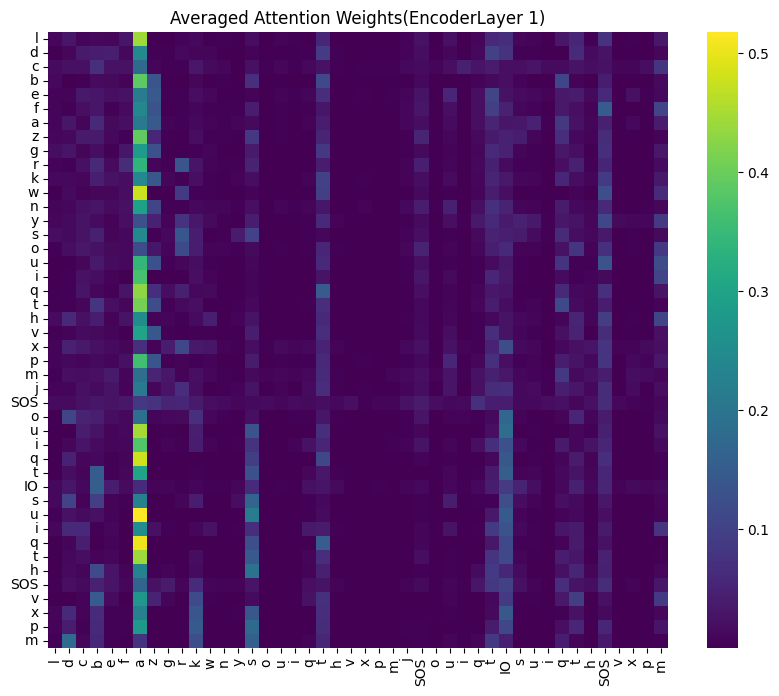

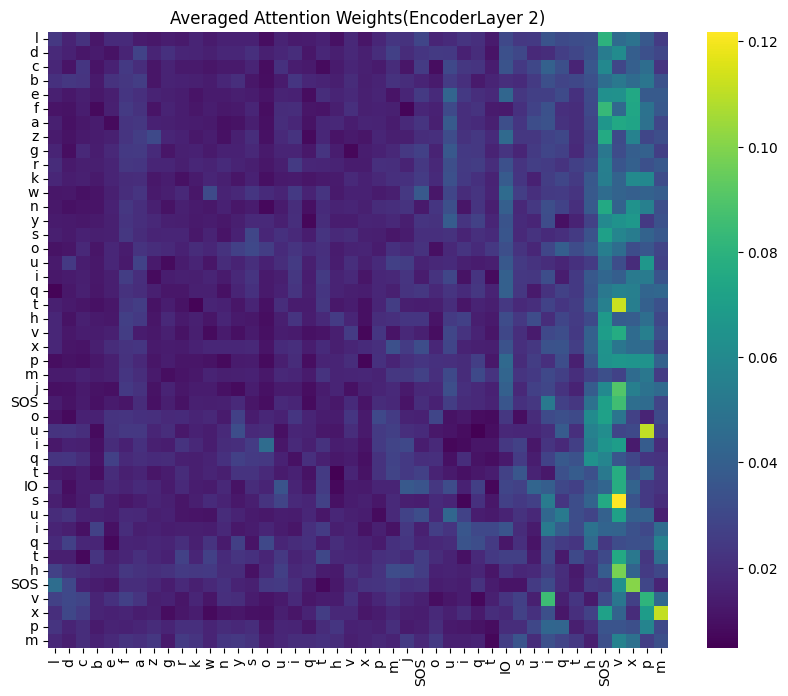

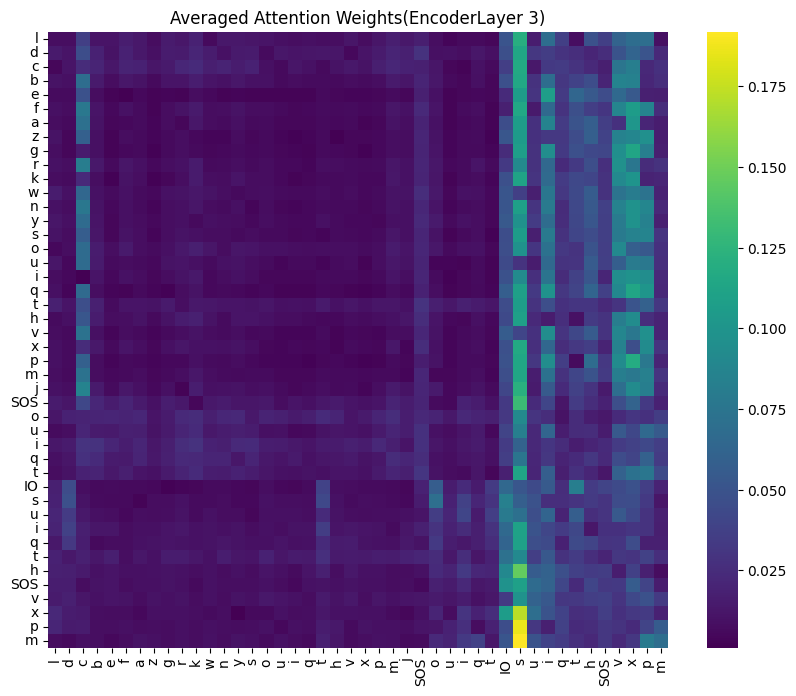

extend_pred


In [ ]:
get_encoder_attention_plots(model, batch, idx=3)
print(batch["transformation"][3])

In [ ]:
model.transformer.encoder.layers[0].self_attn._qkv_same_embed_dim

True